<a href="https://colab.research.google.com/github/JoshiRawr/Deep-Learning/blob/main/DEEP_LEARNING_PROJ.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [161]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [162]:
import os
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

from sklearn.metrics import confusion_matrix, classification_report

In [163]:
dataset_path = "/content/drive/MyDrive/WasteSegregation"

image_paths = []
labels = []

valid_ext = ('.jpg', '.jpeg', '.png', '.bmp', '.webp', '.JPG', '.PNG')

for class_name in os.listdir(dataset_path):
    class_path = os.path.join(dataset_path, class_name)

    if os.path.isdir(class_path):
        for file in os.listdir(class_path):
            if file.endswith(valid_ext):
                image_paths.append(os.path.join(class_path, file))
                labels.append(class_name)

print("Total images:", len(image_paths))
print("Classes:", set(labels))

Total images: 398
Classes: {'Hazardous', 'Non-Recyclable', 'Organic', 'Recyclable'}


In [164]:
le = LabelEncoder()
labels_encoded = le.fit_transform(labels)
labels_categorical = to_categorical(labels_encoded)

class_names = le.classes_

print("Classes:", class_names)

Classes: ['Hazardous' 'Non-Recyclable' 'Organic' 'Recyclable']


In [165]:
train_paths, val_paths, train_labels, val_labels = train_test_split(
    image_paths,
    labels_categorical,
    test_size=0.2,
    random_state=42,
    stratify=labels_encoded
)

In [166]:
def process_image(path, label):
    img = tf.io.read_file(path)

    # safe decoder (handles jpg/png/webp)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)

    img = tf.image.resize(img, (128, 128))
    img = tf.cast(img, tf.float32) / 255.0

    return img, label

In [167]:
train_ds = tf.data.Dataset.from_tensor_slices((train_paths, train_labels))

train_ds = train_ds.map(process_image, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.shuffle(500).batch(32).prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((val_paths, val_labels))

val_ds = val_ds.map(process_image, num_parallel_calls=tf.data.AUTOTUNE)
val_ds = val_ds.batch(32).prefetch(tf.data.AUTOTUNE)

In [168]:
model = models.Sequential()

model.add(layers.Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)))
model.add(layers.MaxPooling2D())

model.add(layers.Conv2D(64, (3,3), activation='relu'))
model.add(layers.MaxPooling2D())

model.add(layers.Conv2D(128, (3,3), activation='relu'))
model.add(layers.MaxPooling2D())

model.add(layers.Flatten())

model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dropout(0.5))

model.add(layers.Dense(len(class_names), activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [169]:
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [170]:
early_stop = EarlyStopping(patience=10, restore_best_weights=True)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=[early_stop]
)

Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 55s 2s/step - accuracy: 0.2201 - loss: 1.3910 - val_accuracy: 0.3375 - val_loss: 1.3708
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 46s 2s/step - accuracy: 0.3711 - loss: 1.3394 - val_accuracy: 0.4250 - val_loss: 1.3428
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 47s 2s/step - accuracy: 0.3962 - loss: 1.3048 - val_accuracy: 0.4250 - val_loss: 1.2968
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 49s 3s/step - accuracy: 0.4686 - loss: 1.2301 - val_accuracy: 0.4375 - val_loss: 1.2577
Epoch 5/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 75s 2s/step - accuracy: 0.5000 - loss: 1.1917 - val_accuracy: 0.4500 - val_loss: 1.2425
Epoch 6/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 84s 2s/step - accuracy: 0.4811 - loss: 1.1513 - val_accuracy: 0.4375 - val_loss: 1.2062
Epoch 7/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 84s 2s/step - accuracy: 0.5031 - loss: 1.1289 - val_accuracy: 0.4500 - val_loss: 1.1862
Epoch 8/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 41s 2s/step - accuracy: 0.5818 - loss: 1.0634 - val_accuracy: 0.4875 - val_loss:

In [172]:
loss, acc = model.evaluate(val_ds)
print("Validation Accuracy:", acc)

3/3 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.5000 - loss: 1.1675
Validation Accuracy: 0.5


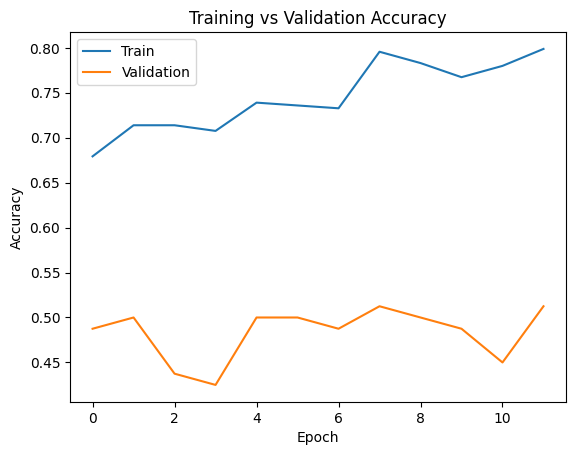

In [173]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])

plt.show()

In [174]:
from google.colab import files
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

Saving Recycle8.jpg to Recycle8 (1).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step
Predicted Class: Non-Recyclable


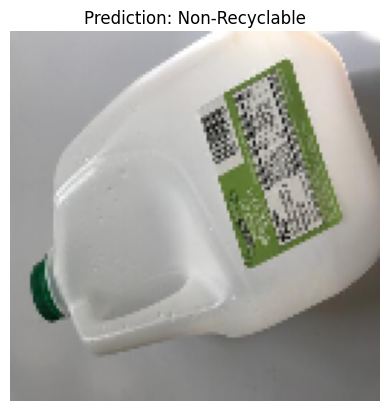

In [175]:
uploaded = files.upload()
filename = list(uploaded.keys())[0]

img = image.load_img(filename, target_size=(128,128))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)
predicted_class = np.argmax(prediction)

class_labels = list(train_data.class_indices.keys())

plt.imshow(img)
plt.axis('off')

print("Predicted Class:", class_labels[predicted_class])
plt.title("Prediction: " + class_labels[predicted_class])
plt.show()

Saving ph-11134103-23020-i4s9w288v9mvf2.webp to ph-11134103-23020-i4s9w288v9mvf2 (2).webp
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
Predicted Class: Hazardous


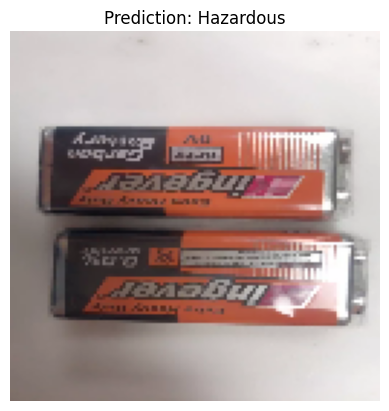

In [176]:
uploaded = files.upload()
filename = list(uploaded.keys())[0]

img = image.load_img(filename, target_size=(128,128))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)
predicted_class = np.argmax(prediction)

class_labels = list(train_data.class_indices.keys())

plt.imshow(img)
plt.axis('off')

print("Predicted Class:", class_labels[predicted_class])
plt.title("Prediction: " + class_labels[predicted_class])
plt.show()

3/3 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step


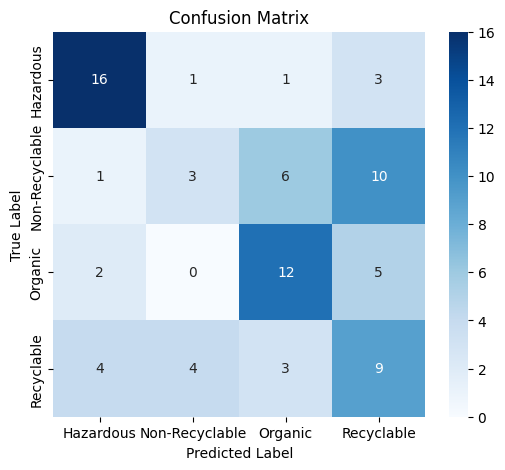

In [178]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import numpy as np

# 🔹 Get predictions
predictions = model.predict(val_ds)
pred_classes = np.argmax(predictions, axis=1)

# 🔹 Get true labels
true_classes = np.argmax(val_labels, axis=1)

# 🔹 Create confusion matrix
cm = confusion_matrix(true_classes, pred_classes)

# 🔹 Plot
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

Image path: /content/drive/MyDrive/WasteSegregation/Hazardous/ph-11134103-23020-mwibyd9u6pnv74.webp
True Label: Hazardous
Predicted: Hazardous
Confidence: 87.71%
Result: CORRECT


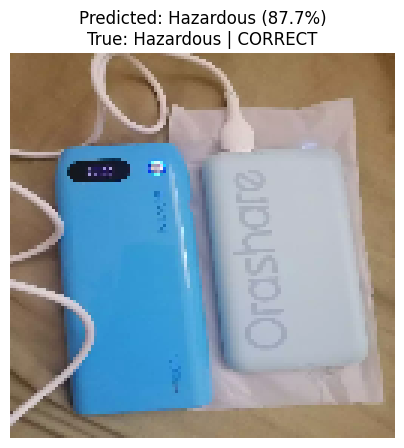

In [188]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

def predict_random():
    if len(val_paths) == 0:
        print("ERROR: val_paths is empty.")
        return

    idx = np.random.randint(len(val_paths))

    img_path = val_paths[idx]
    true_label = np.argmax(val_labels[idx])

    img = tf.keras.preprocessing.image.load_img(img_path, target_size=(128,128))
    img_array = tf.keras.preprocessing.image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    pred = model.predict(img_array, verbose=0)
    pred_class = np.argmax(pred)
    confidence = np.max(pred) * 100

    result = "CORRECT" if pred_class == true_label else "WRONG"

    print("Image path:", img_path)
    print("True Label:", class_names[true_label])
    print("Predicted:", class_names[pred_class])
    print(f"Confidence: {confidence:.2f}%")
    print("Result:", result)

    plt.figure(figsize=(5,5))
    plt.imshow(img)
    plt.axis("off")
    plt.title(
        f"Predicted: {class_names[pred_class]} ({confidence:.1f}%)\n"
        f"True: {class_names[true_label]} | {result}"
    )
    plt.show()

predict_random()

Image path: /content/drive/MyDrive/WasteSegregation/Organic/IMG_5640.JPG
True Label: Organic
Predicted: Organic
Confidence: 76.71%
Result: CORRECT


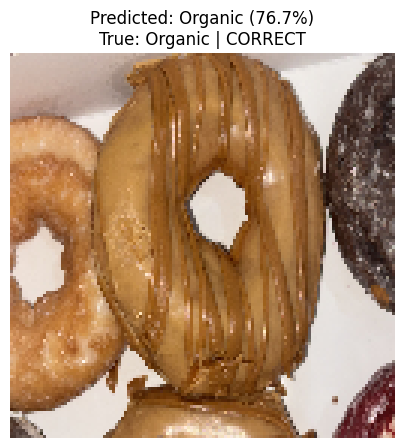

In [197]:
Ximport numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

def predict_random():
    if len(val_paths) == 0:
        print("ERROR: val_paths is empty.")
        return

    idx = np.random.randint(len(val_paths))

    img_path = val_paths[idx]
    true_label = np.argmax(val_labels[idx])

    img = tf.keras.preprocessing.image.load_img(img_path, target_size=(128,128))
    img_array = tf.keras.preprocessing.image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    pred = model.predict(img_array, verbose=0)
    pred_class = np.argmax(pred)
    confidence = np.max(pred) * 100

    result = "CORRECT" if pred_class == true_label else "WRONG"

    print("Image path:", img_path)
    print("True Label:", class_names[true_label])
    print("Predicted:", class_names[pred_class])
    print(f"Confidence: {confidence:.2f}%")
    print("Result:", result)

    plt.figure(figsize=(5,5))
    plt.imshow(img)
    plt.axis("off")
    plt.title(
        f"Predicted: {class_names[pred_class]} ({confidence:.1f}%)\n"
        f"True: {class_names[true_label]} | {result}"
    )
    plt.show()

predict_random()

Image path: /content/drive/MyDrive/WasteSegregation/Organic/IMG_5173.JPG
True Label: Organic
Predicted: Organic
Confidence: 38.76%
Result: CORRECT


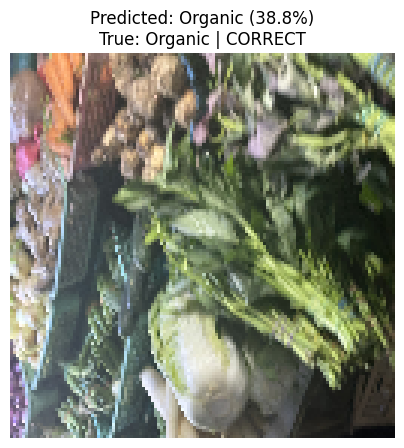

In [185]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

def predict_random():
    if len(val_paths) == 0:
        print("ERROR: val_paths is empty.")
        return

    idx = np.random.randint(len(val_paths))

    img_path = val_paths[idx]
    true_label = np.argmax(val_labels[idx])

    img = tf.keras.preprocessing.image.load_img(img_path, target_size=(128,128))
    img_array = tf.keras.preprocessing.image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    pred = model.predict(img_array, verbose=0)
    pred_class = np.argmax(pred)
    confidence = np.max(pred) * 100

    result = "CORRECT" if pred_class == true_label else "WRONG"

    print("Image path:", img_path)
    print("True Label:", class_names[true_label])
    print("Predicted:", class_names[pred_class])
    print(f"Confidence: {confidence:.2f}%")
    print("Result:", result)

    plt.figure(figsize=(5,5))
    plt.imshow(img)
    plt.axis("off")
    plt.title(
        f"Predicted: {class_names[pred_class]} ({confidence:.1f}%)\n"
        f"True: {class_names[true_label]} | {result}"
    )
    plt.show()

predict_random()

Image path: /content/drive/MyDrive/WasteSegregation/Hazardous/IMG_5525.JPG
True Label: Hazardous
Predicted: Hazardous
Confidence: 61.31%
Result: CORRECT


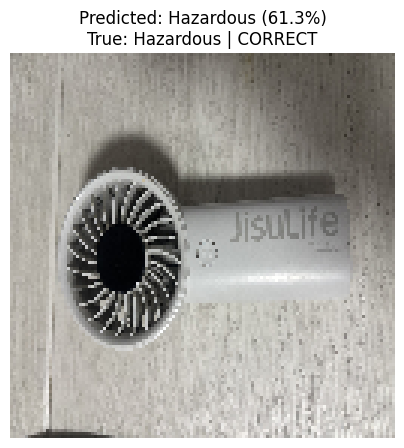

In [196]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

def predict_random():
    if len(val_paths) == 0:
        print("ERROR: val_paths is empty.")
        return

    idx = np.random.randint(len(val_paths))

    img_path = val_paths[idx]
    true_label = np.argmax(val_labels[idx])

    img = tf.keras.preprocessing.image.load_img(img_path, target_size=(128,128))
    img_array = tf.keras.preprocessing.image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    pred = model.predict(img_array, verbose=0)
    pred_class = np.argmax(pred)
    confidence = np.max(pred) * 100

    result = "CORRECT" if pred_class == true_label else "WRONG"

    print("Image path:", img_path)
    print("True Label:", class_names[true_label])
    print("Predicted:", class_names[pred_class])
    print(f"Confidence: {confidence:.2f}%")
    print("Result:", result)

    plt.figure(figsize=(5,5))
    plt.imshow(img)
    plt.axis("off")
    plt.title(
        f"Predicted: {class_names[pred_class]} ({confidence:.1f}%)\n"
        f"True: {class_names[true_label]} | {result}"
    )
    plt.show()

predict_random()

Image path: /content/drive/MyDrive/WasteSegregation/Non-Recyclable/IMG_5560.JPG
True Label: Non-Recyclable
Predicted: Recyclable
Confidence: 38.05%
Result: WRONG


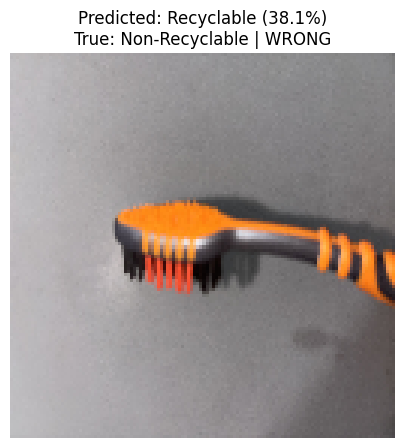

In [190]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

def predict_random():
    if len(val_paths) == 0:
        print("ERROR: val_paths is empty.")
        return

    idx = np.random.randint(len(val_paths))

    img_path = val_paths[idx]
    true_label = np.argmax(val_labels[idx])

    img = tf.keras.preprocessing.image.load_img(img_path, target_size=(128,128))
    img_array = tf.keras.preprocessing.image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    pred = model.predict(img_array, verbose=0)
    pred_class = np.argmax(pred)
    confidence = np.max(pred) * 100

    result = "CORRECT" if pred_class == true_label else "WRONG"

    print("Image path:", img_path)
    print("True Label:", class_names[true_label])
    print("Predicted:", class_names[pred_class])
    print(f"Confidence: {confidence:.2f}%")
    print("Result:", result)

    plt.figure(figsize=(5,5))
    plt.imshow(img)
    plt.axis("off")
    plt.title(
        f"Predicted: {class_names[pred_class]} ({confidence:.1f}%)\n"
        f"True: {class_names[true_label]} | {result}"
    )
    plt.show()

predict_random()

Image path: /content/drive/MyDrive/WasteSegregation/Organic/IMG_5179.JPG
True Label: Organic
Predicted: Organic
Confidence: 46.47%
Result: CORRECT


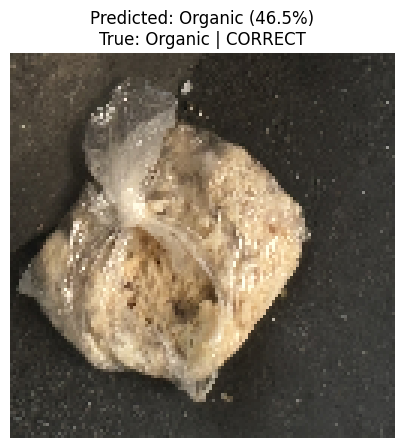

In [194]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

def predict_random():
    if len(val_paths) == 0:
        print("ERROR: val_paths is empty.")
        return

    idx = np.random.randint(len(val_paths))

    img_path = val_paths[idx]
    true_label = np.argmax(val_labels[idx])

    img = tf.keras.preprocessing.image.load_img(img_path, target_size=(128,128))
    img_array = tf.keras.preprocessing.image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    pred = model.predict(img_array, verbose=0)
    pred_class = np.argmax(pred)
    confidence = np.max(pred) * 100

    result = "CORRECT" if pred_class == true_label else "WRONG"

    print("Image path:", img_path)
    print("True Label:", class_names[true_label])
    print("Predicted:", class_names[pred_class])
    print(f"Confidence: {confidence:.2f}%")
    print("Result:", result)

    plt.figure(figsize=(5,5))
    plt.imshow(img)
    plt.axis("off")
    plt.title(
        f"Predicted: {class_names[pred_class]} ({confidence:.1f}%)\n"
        f"True: {class_names[true_label]} | {result}"
    )
    plt.show()

predict_random()